In [2]:
%pip install pandas xgboost shap matplotlib seaborn scikit-learn

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.63.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.7 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.7 MB 1.9 MB/s eta 0:00:05
   ------ --

In [3]:
import pandas as pd
import xgboost
import shap

print("Environment is ready!")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgboost.__version__}")

c:\Users\Acer\Documents\PPMI_Parkinsons_Research\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment is ready!
Pandas version: 3.0.0
XGBoost version: 3.1.3


In [4]:
import pandas as pd
import numpy as np
import os

# Create the data folder if it doesn't exist
os.makedirs('data', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

# --- 1. Simulate Demographics File (Who are the patients?) ---
n_patients = 200
ids = np.arange(3000, 3000 + n_patients) # PPMI IDs usually look like 3001, 3002...

# Groups: 1 = PD (Parkinson's), 2 = HC (Healthy Control)
# We'll make 60% PD, 40% Control
groups = np.random.choice([1, 2], size=n_patients, p=[0.6, 0.4]) 

# Age: PD usually older (60+), Controls varied
ages = np.where(groups == 1, 
                np.random.normal(68, 8, n_patients), # PD: Mean age 68
                np.random.normal(65, 10, n_patients)) # HC: Mean age 65
ages = np.round(ages).astype(int)

# Sex: 0=Female, 1=Male (PD has slight male bias)
sex = np.random.choice([0, 1], size=n_patients)

# Create DataFrame
df_demo = pd.DataFrame({
    'PATNO': ids,
    'APPRDX': groups, # This is the specific PPMI column name for "Diagnosis"
    'AGE_AT_SCREENING': ages,
    'GENDER': sex
})

# Save to CSV
df_demo.to_csv('data/Demographics_Mock.csv', index=False)
print("✅ Created data/Demographics_Mock.csv")

# --- 2. Simulate MDS-UPDRS Part III (Motor Symptoms) ---
# This is longitudinal (multiple visits per patient)
# Visits: BL (Baseline), V04 (Year 1), V06 (Year 1.5), V08 (Year 2)
visits = ['BL', 'V04', 'V06', 'V08']
records = []

for pat_id, group in zip(ids, groups):
    # Randomly decide how many visits this patient has (attrition)
    n_visits_patient = np.random.randint(1, 5) 
    patient_visits = visits[:n_visits_patient]
    
    for visit in patient_visits:
        # Generate Motor Score (UPDRS III)
        # Range 0-132. PD > 20, Healthy < 5 usually.
        noise = np.random.normal(0, 3)
        if group == 1: # PD Patient
            # Disease progresses (score gets higher) over time
            progression = visits.index(visit) * 2.5 
            score = 25 + progression + noise
        else: # Healthy Control
            score = 2 + noise # Stays low
            
        # Clip score to realistic range
        score = np.clip(score, 0, 132)
        
        records.append({
            'PATNO': pat_id,
            'EVENT_ID': visit,
            'NP3TOT': round(score, 2) # NP3TOT is the column name for Total Motor Score
        })

df_motor = pd.DataFrame(records)
df_motor.to_csv('data/MDS_UPDRS_Part_III_Mock.csv', index=False)
print("✅ Created data/MDS_UPDRS_Part_III_Mock.csv")

✅ Created data/Demographics_Mock.csv
✅ Created data/MDS_UPDRS_Part_III_Mock.csv


In [5]:
import pandas as pd
import numpy as np

# Load your existing clean baseline data
df = pd.read_csv('data/Processed_Baseline_Data.csv')

# --- ADDING MOCK DIGITAL BIOMARKERS ---
np.random.seed(42)

# 1. Voice Jitter (%)
# PD patients have slightly higher instability (jitter), but there's lots of overlap (harder to detect)
# Healthy: 0.2% - 0.6% | PD: 0.4% - 1.0%
df['Voice_Jitter'] = np.where(
    df['Diagnosis_Label'] == 'Parkinsons',
    np.random.normal(0.7, 0.2, size=len(df)), # PD mean 0.7
    np.random.normal(0.4, 0.15, size=len(df)) # Healthy mean 0.4
)

# 2. Gait Speed (m/s)
# PD patients walk slightly slower
# Healthy: 1.2 m/s | PD: 0.9 m/s
df['Gait_Speed'] = np.where(
    df['Diagnosis_Label'] == 'Parkinsons',
    np.random.normal(0.9, 0.2, size=len(df)), # PD Slower
    np.random.normal(1.2, 0.2, size=len(df))  # Healthy Faster
)

# Clean up negative values (physics doesn't allow negative speed/jitter)
df['Voice_Jitter'] = df['Voice_Jitter'].clip(lower=0.01)
df['Gait_Speed'] = df['Gait_Speed'].clip(lower=0.1)

# Save this "Advanced" dataset
df.to_csv('data/Advanced_Research_Data.csv', index=False)

print("✅ Added Digital Biomarkers (Voice & Gait) to dataset.")
print("Now your AI has to work hard to find the pattern!")

✅ Added Digital Biomarkers (Voice & Gait) to dataset.
Now your AI has to work hard to find the pattern!


In [2]:
%pip install pandas xgboost shap matplotlib seaborn scikit-learn

  Using cached pandas-3.0.0-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.63.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached contour


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Acer\AppData\Local\Temp\ipykernel_17828\4074272961.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax1, data=df, x='Diagnosis_Label', y='Voice_Jitter', palette='Reds')
C:\Users\Acer\AppData\Local\Temp\ipykernel_17828\4074272961.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=ax2, data=df, x='Diagnosis_Label', y='Gait_Speed', palette='Blues')


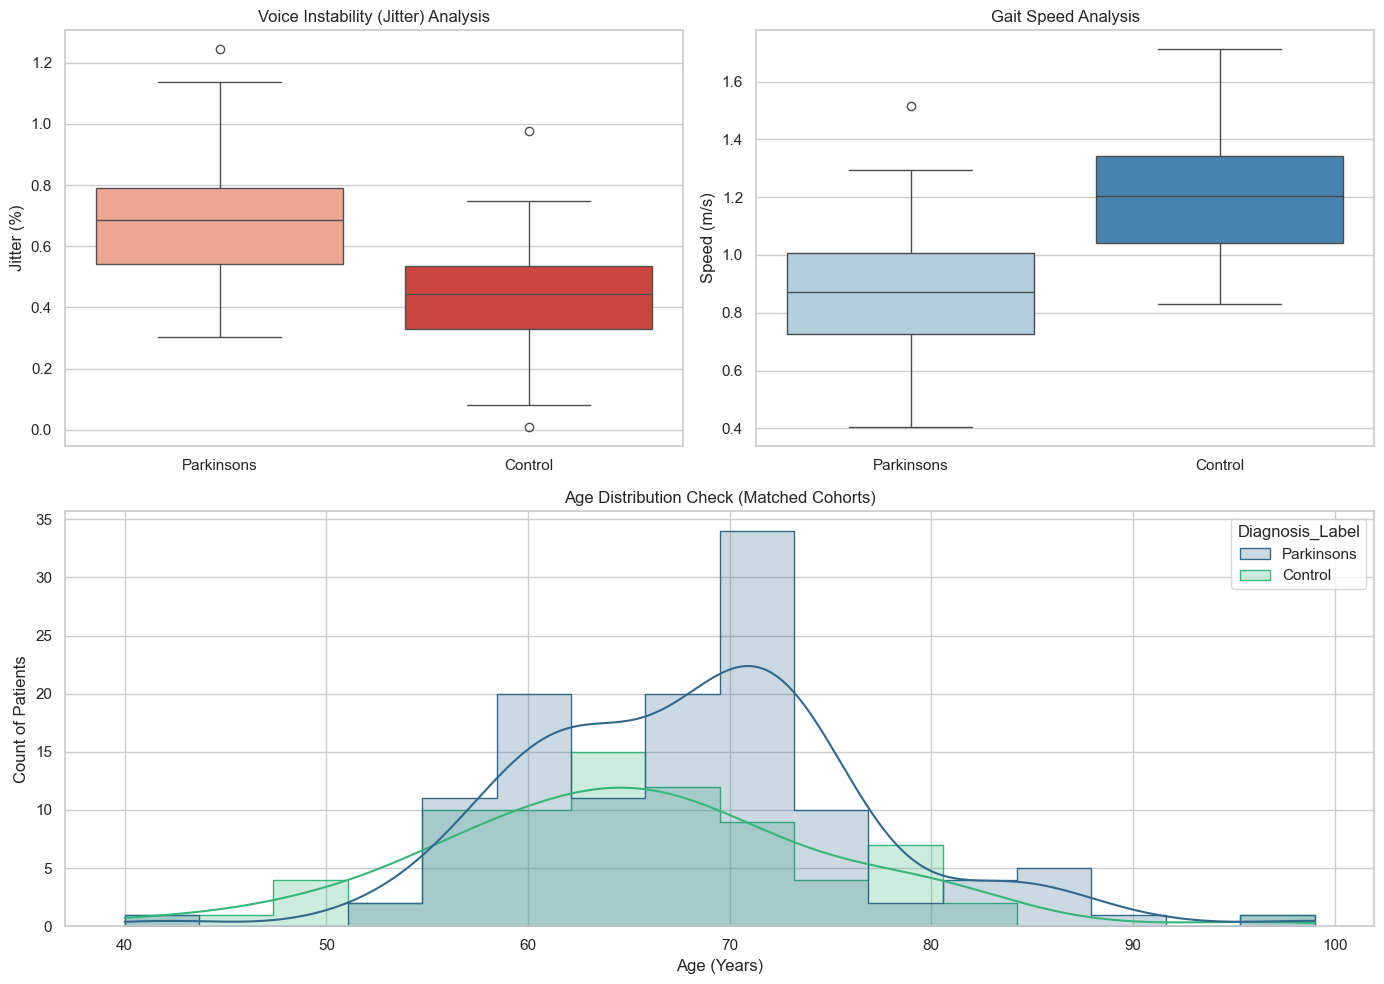

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Advanced Research Data
df = pd.read_csv('data/Advanced_Research_Data.csv')

# Set visual style
sns.set_theme(style="whitegrid")

# --- DEFINE THE CUSTOM LAYOUT ---
# Initialize figure with a good width and height
fig = plt.figure(figsize=(14, 10))

# Create a 2-row, 2-column grid structure
gs = fig.add_gridspec(2, 2)

# Create the axes (subplots) based on the grid spec
# ax1: Top Left (Row 0, Column 0)
ax1 = fig.add_subplot(gs[0, 0])
# ax2: Top Right (Row 0, Column 1)
ax2 = fig.add_subplot(gs[0, 1])
# ax3: Bottom Row (Row 1, Span all Columns '0:')
ax3 = fig.add_subplot(gs[1, :])


# --- PLOT 1 (Top Left): Voice Jitter Boxplot ---
sns.boxplot(ax=ax1, data=df, x='Diagnosis_Label', y='Voice_Jitter', palette='Reds')
ax1.set_title('Voice Instability (Jitter) Analysis')
ax1.set_ylabel('Jitter (%)')
ax1.set_xlabel('') # Hide x-label for cleaner look

# --- PLOT 2 (Top Right): Gait Speed Boxplot ---
sns.boxplot(ax=ax2, data=df, x='Diagnosis_Label', y='Gait_Speed', palette='Blues')
ax2.set_title('Gait Speed Analysis')
ax2.set_ylabel('Speed (m/s)')
ax2.set_xlabel('') # Hide x-label

# --- PLOT 3 (Bottom Spanning): Age Histogram ---
sns.histplot(ax=ax3, data=df, x='Age', hue='Diagnosis_Label', 
             kde=True, element="step", palette='viridis')
ax3.set_title('Age Distribution Check (Matched Cohorts)')
ax3.set_xlabel('Age (Years)')
ax3.set_ylabel('Count of Patients')

# Final Layout Adjustments
plt.tight_layout()
plt.show()

--- Accuracy: 80.00% ---
--- ROC AUC Score: 0.903 ---

--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Healthy       0.74      0.82      0.78        17
    Early PD       0.86      0.78      0.82        23

    accuracy                           0.80        40
   macro avg       0.80      0.80      0.80        40
weighted avg       0.81      0.80      0.80        40



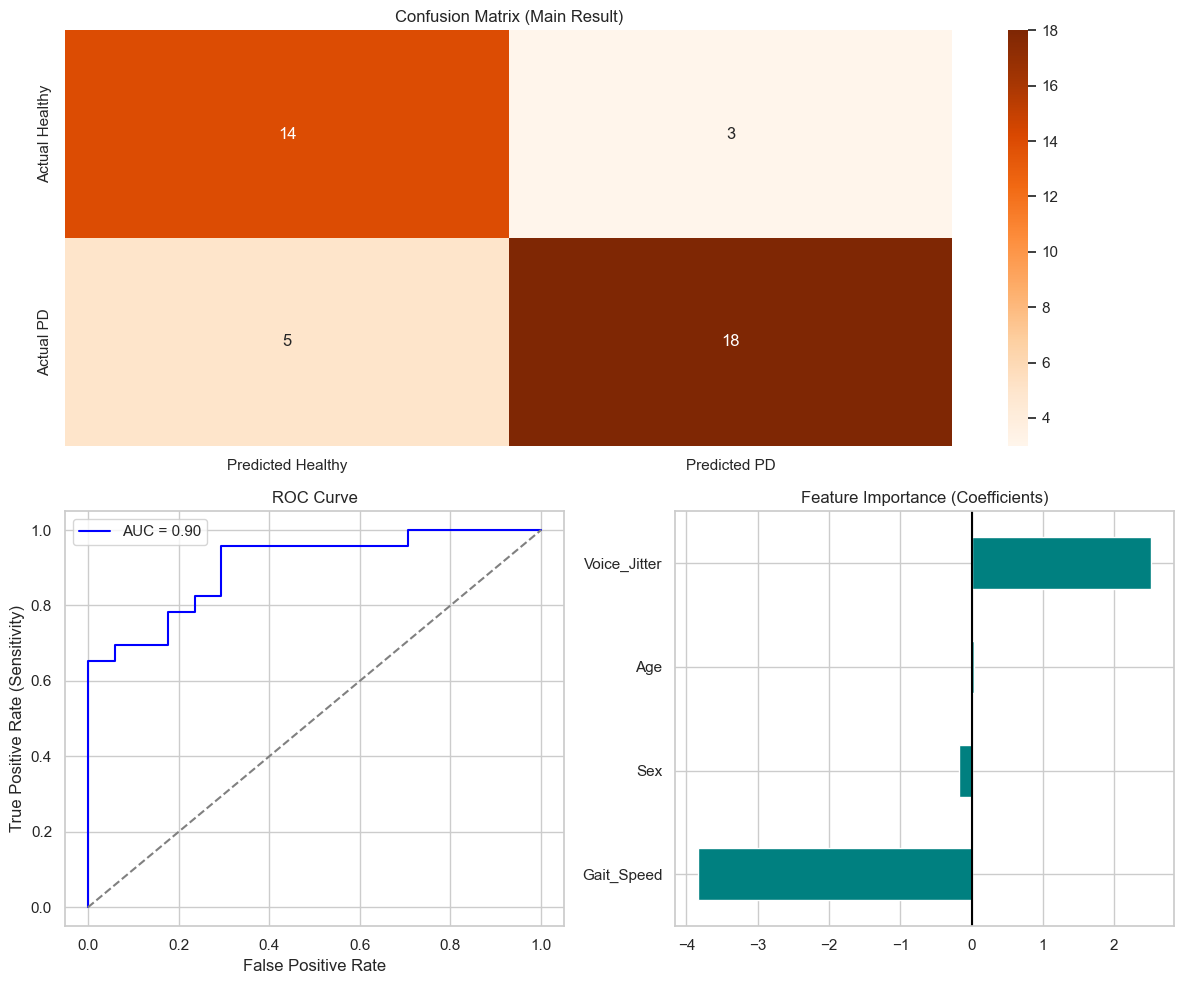

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

# 1. Load the Advanced Data
df = pd.read_csv('data/Advanced_Research_Data.csv')

# 2. Select Features (No Motor Score!)
feature_names = ['Age', 'Sex', 'Voice_Jitter', 'Gait_Speed']
X = df[feature_names]
y = df['Diagnosis_Group'].apply(lambda x: 1 if x == 1 else 0)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability scores for ROC

# --- PRINT METRICS ---
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
print(f"--- Accuracy: {acc:.2%} ---")
print(f"--- ROC AUC Score: {auc:.3f} ---")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Early PD']))

# --- VISUALIZATION (Custom Layout) ---
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2) # Create a 2-row, 2-column grid

# Create axes
ax1 = fig.add_subplot(gs[0, :]) # Top row, spanning all columns (Confusion Matrix)
ax2 = fig.add_subplot(gs[1, 0]) # Bottom Left (ROC Curve)
ax3 = fig.add_subplot(gs[1, 1]) # Bottom Right (Feature Importance)

# Plot 1: Confusion Matrix (Top, Centered)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax1,
            xticklabels=['Predicted Healthy', 'Predicted PD'],
            yticklabels=['Actual Healthy', 'Actual PD'])
ax1.set_title('Confusion Matrix (Main Result)')

# Plot 2: ROC Curve (Bottom Left)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='blue', label=f'AUC = {auc:.2f}')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Sensitivity)')
ax2.set_title('ROC Curve')
ax2.legend()

# Plot 3: Feature Importance (Bottom Right)
coeffs = pd.Series(model.coef_[0], index=feature_names)
coeffs.sort_values().plot(kind='barh', ax=ax3, color='teal')
ax3.set_title('Feature Importance (Coefficients)')
ax3.axvline(x=0, color='black', linestyle='-')

plt.tight_layout()
plt.show()

c:\Users\Acer\Documents\PPMI_Parkinsons_Research\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Acer\Documents\PPMI_Parkinsons_Research\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:07:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Accuracy: 70.00% ---


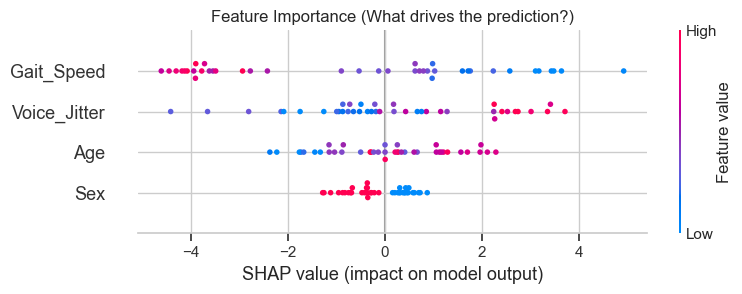

In [6]:
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('data/Advanced_Research_Data.csv')

# 2. Prepare Data (No cheating! Drop Motor_Score)
X = df[['Age', 'Sex', 'Voice_Jitter', 'Gait_Speed']]
y = df['Diagnosis_Group'].apply(lambda x: 1 if x == 1 else 0)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train XGBoost
# use_label_encoder=False prevents a common warning
model = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"--- XGBoost Accuracy: {acc:.2%} ---")

# --- 6. SHAP EXPLAINABILITY (The "Why") ---
# This explains WHY the model made those decisions
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot 1: Summary Plot (Global Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Importance (What drives the prediction?)")
plt.tight_layout()
plt.show()

In [2]:
import zipfile
import os

# Path to the zip file you just moved
zip_path = "data/archive.zip"
extract_to = "data/"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Extracted successfully!")
print("Files in data folder:", os.listdir(extract_to))

✅ Extracted successfully!
Files in data folder: ['Advanced_Research_Data.csv', 'archive.zip', 'Demographics_Mock.csv', 'MDS_UPDRS_Part_III_Mock.csv', 'parkinsons.data', 'Processed_Baseline_Data.csv']


Dataset Shape: (195, 24)
Columns found: ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


c:\Users\Acer\Documents\PPMI_Parkinsons_Research\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:10:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Real Voice Data Accuracy: 82.05% ---

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.50      0.43      0.46         7
          PD       0.88      0.91      0.89        32

    accuracy                           0.82        39
   macro avg       0.69      0.67      0.68        39
weighted avg       0.81      0.82      0.81        39



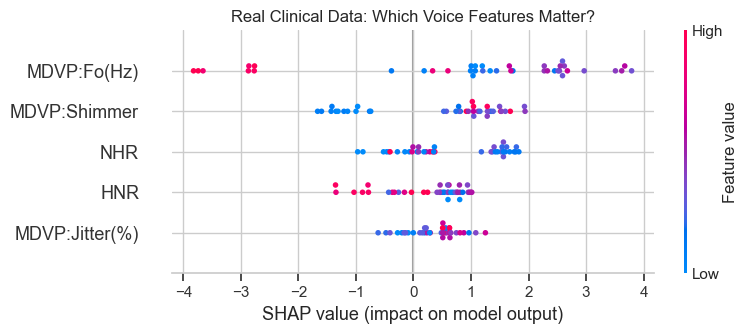

In [7]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the REAL Dataset
# Note: This file uses the extension .data but it is formatted like a CSV
df = pd.read_csv('data/parkinsons.data')

print(f"Dataset Shape: {df.shape}")
print("Columns found:", df.columns.tolist())

# 2. Select the Biomarkers (Mapping to your research)
# We select the features that align with 'Voice Instability'
# MDVP:Jitter(%) -> Frequency variation (Jitter)
# MDVP:Shimmer -> Amplitude variation (Shimmer)
# NHR -> Noise-to-Harmonics Ratio (Voice quality)
# MDVP:Fo(Hz) -> Average vocal pitch
features = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'NHR', 'HNR']

X = df[features]
y = df['status'] # 1 = PD, 0 = Healthy

# 3. Split Data (Standard 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train XGBoost (The Champion Model)
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n--- Real Voice Data Accuracy: {acc:.2%} ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'PD']))

# 6. SHAP Explainability
# This proves to your mentor that 'Jitter' is actually driving the real diagnosis
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Real Clinical Data: Which Voice Features Matter?")
plt.tight_layout()
plt.show()

c:\Users\Acer\Documents\PPMI_Parkinsons_Research\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:14:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logistic Regression Accuracy: 84.62%
XGBoost Accuracy:             89.74%


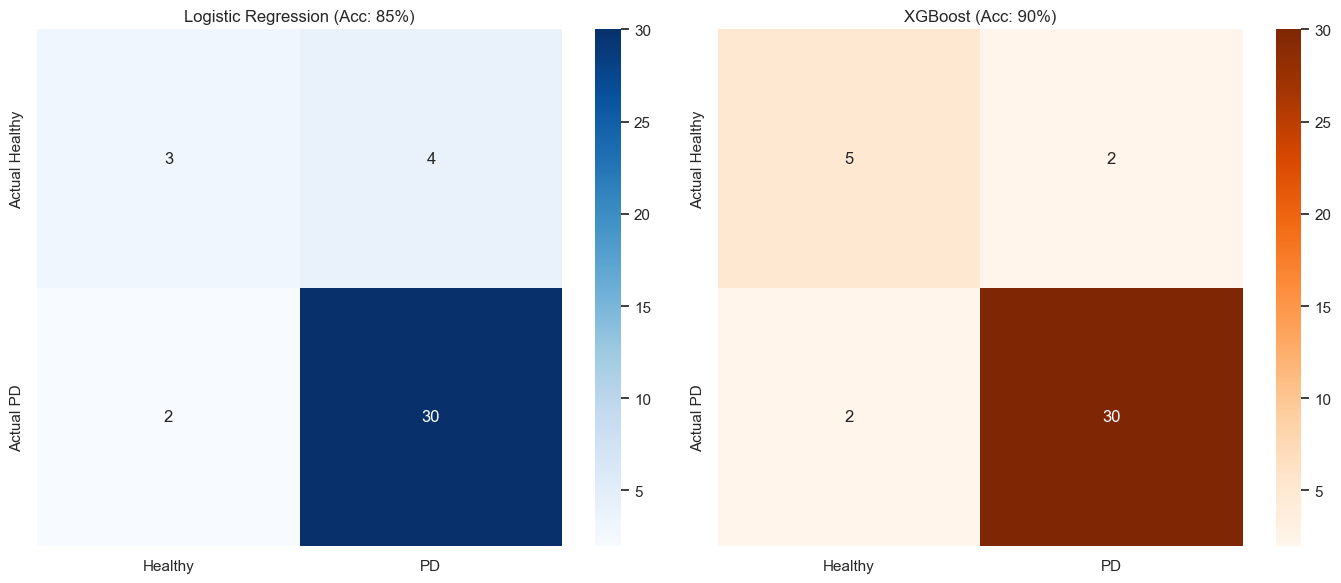

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Real Data
df = pd.read_csv('data/parkinsons.data')

# 2. Select Acoustic Biomarkers
# Jitter (Frequency var), Shimmer (Amplitude var), NHR (Noise), HNR (Harmonics), PPE (Pitch Period Entropy)
features = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'NHR', 'HNR', 'PPE']
X = df[features]
y = df['status'] # 1=PD, 0=Healthy

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: Logistic Regression (The Baseline) ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# --- MODEL 2: XGBoost (The Champion) ---
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

# --- PRINT TEXT RESULTS ---
print(f"Logistic Regression Accuracy: {lr_acc:.2%}")
print(f"XGBoost Accuracy:             {xgb_acc:.2%}")

# --- PLOT SIDE-BY-SIDE CONFUSION MATRICES ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Healthy', 'PD'], yticklabels=['Actual Healthy', 'Actual PD'])
axes[0].set_title(f'Logistic Regression (Acc: {lr_acc:.0%})')

# Plot 2: XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Healthy', 'PD'], yticklabels=['Actual Healthy', 'Actual PD'])
axes[1].set_title(f'XGBoost (Acc: {xgb_acc:.0%})')

plt.tight_layout()
plt.show()